In [124]:
# Credit and aknolwedgements:
# https://towardsdatascience.com/implementing-gradient-descent-in-python-from-scratch-760a8556c31f/
# Use: As a tutorial to practise coding gradient descet in python

# Dataset from: https://www.kaggle.com/datasets/ashydv/advertising-dataset?resource=download

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import random as rd
import math

In [126]:
url = 'advertising.csv'
df = pd.read_csv(url)

In [127]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [128]:
X = df[['TV','Radio','Newspaper']]
Y = df['Sales']

## 1. The Hypothesis and Cost Function

We represent our prediction as a linear combination of inputs. The "Cost" is how far off our predictions are from the real values.

**The Prediction (Linear Regression):**


$$\hat{Y} = b + \theta_1X_1 + \theta_2X_2 + ... + \theta_nX_n$$

**The Cost Function (MSE):**


$$J(b, \theta) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$

In [129]:
Y = np.array((Y-Y.mean())/Y.std())
X = X.apply(lambda x:(x-x.mean())/x.std(), axis=0)

In [130]:
def initialise(dim):
    b=rd.random()
    theta = np.random.rand(dim)
    return b, theta

b, theta = initialise(3)

print("Bias: ",b,"Weights: ",theta)

Bias:  0.6516204329552207 Weights:  [0.72871297 0.47593083 0.33567294]


In [131]:
def predict_Y(b, theta, X):
    return b + np.dot(X, theta)

Y_hat=predict_Y(b, theta, X)
Y_hat[0:10]

array([ 2.41821191,  0.51950945,  0.87235654,  1.69834911,  0.96778904,
        0.98423246,  0.08856623,  0.01419611, -1.65740069,  0.29283508])

In [132]:
def get_cost(Y, Y_hat):
    Y_resd=Y-Y_hat
    return np.sum(np.dot(Y_resd.T, Y_resd)) / len(Y - Y_resd)

Y_hat = predict_Y(b, theta, X)
get_cost(Y, Y_hat)

np.float64(0.7199157786621382)

## 2. The Gradient Update

To "descend" the gradient, we calculate the partial derivative of the cost function with respect to $b$ and $\theta$. This tells us the direction of the steepest increase; we move in the **opposite** direction.

**The Update Rules:**


$$b = b - \alpha \frac{\partial J}{\partial b}$$

$$\theta = \theta - \alpha \frac{\partial J}{\partial \theta}$$

Where the gradients (derivatives) are:


$$\frac{\partial J}{\partial b} = \frac{2}{m} \sum (\hat{Y} - Y)$$

$$\frac{\partial J}{\partial \theta} = \frac{2}{m} \sum (\hat{Y} - Y) \cdot X$$

In [133]:
def update_theta(x,y, y_hat, b_0, theta_o, learning_rate):
    db = (np.sum(y_hat-y)*2)/len(y)
    dw = (np.dot((y_hat - y), x)*2)/len(y)
    b_1 = b_0 - learning_rate * db
    theta_1 = theta_o-learning_rate*dw
    return b_1, theta_1

print('After initialisation -Bias: ', b, 'theta: ', theta)

Y_hat = predict_Y(b,theta,X)
b, theta = update_theta(X, Y, Y_hat, b, theta, 0.01)

print("After first update -Bias: ",b,"theta: ",theta)

get_cost(Y,Y_hat)


After initialisation -Bias:  0.6516204329552207 theta:  [0.72871297 0.47593083 0.33567294]
After first update -Bias:  0.6385880242961163 theta:  [0.73124813 0.47025729 0.32796126]


np.float64(0.7199157786621382)

## 3. The Training Loop

This function ties everything together, iterating through the steps to optimize the parameters over time.

In [134]:
def run_gradient_descent(X, Y, alpha, num_iterations):
    b, theta = initialise(X.shape[1])
    iter_num = 0
    gd_iterations_df = pd.DataFrame(columns=['iteration', 'cost'])
    result_idx = 0

    for each_iter in range(num_iterations):
        Y_hat=predict_Y(b, theta, X)
        this_cost = get_cost(Y, Y_hat)

        prev_b = b
        prev_theta = theta

        b, theta = update_theta(X, Y, Y_hat, prev_b, prev_theta, alpha)

        if (iter_num%10==0):
            gd_iterations_df.loc[result_idx]=[iter_num, this_cost]
            result_idx = result_idx + 1
        
        iter_num += 1
    
    print('Final Estimate of b and theta : ', b, theta)
    return gd_iterations_df, b, theta

gd_iterations_df, b, theta = run_gradient_descent(X, Y, alpha=0.001, num_iterations=200)

Final Estimate of b and theta :  0.508788727913845 [0.54495557 0.31518025 0.10869116]


In [135]:
gd_iterations_df[0:10]

,iteration,cost
0,0.0,0.941318
1,10.0,0.908452
2,20.0,0.876865
3,30.0,0.846509
4,40.0,0.817336
5,50.0,0.789299
6,60.0,0.762355
7,70.0,0.736459
8,80.0,0.711573
9,90.0,0.687656


Text(0, 0.5, 'Cost or MSE')

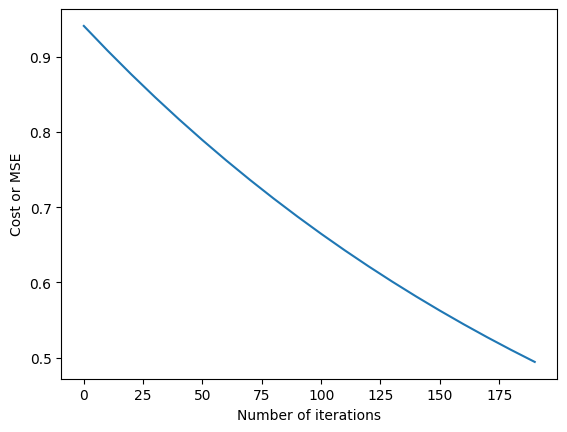

In [136]:
plt.plot(gd_iterations_df['iteration'], gd_iterations_df['cost'])
plt.xlabel('Number of iterations')
plt.ylabel('Cost or MSE')

Final Estimate of b and theta :  -2.7747814828780345e-16 [0.88465106 0.30065466 0.00138348]
Final Estimate of b and theta :  0.0023392162921895845 [0.8745004  0.29788931 0.00836315]


Text(0.5, 1.0, 'Cost Vs. Iterations for different alpha values')

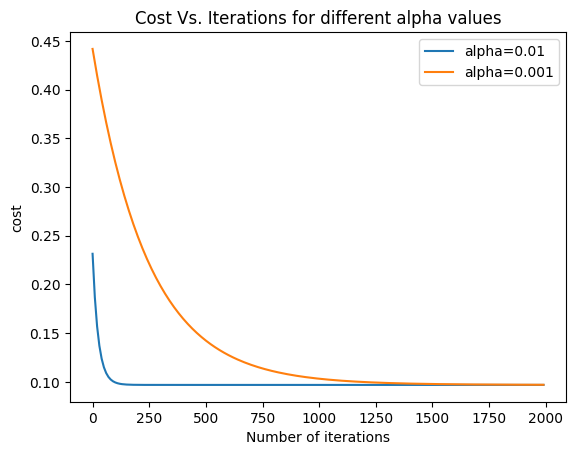

In [137]:
alpha_df_1,b,theta=run_gradient_descent(X,Y,alpha=0.01,num_iterations=2000)
alpha_df_2,b,theta=run_gradient_descent(X,Y,alpha=0.001,num_iterations=2000)

plt.plot(alpha_df_1['iteration'],alpha_df_1['cost'],label="alpha=0.01")
plt.plot(alpha_df_2['iteration'],alpha_df_2['cost'],label="alpha=0.001")

plt.legend()
plt.ylabel('cost')
plt.xlabel('Number of iterations')
plt.title('Cost Vs. Iterations for different alpha values')